In [2]:
!pip install kagglehub

Defaulting to user installation because normal site-packages is not writeable

   ---------------------------------------- 0/2 [kagglesdk]
   ---------------------------------------- 0/2 [kagglesdk]
   ---------------------------------------- 0/2 [kagglesdk]
   ---------------------------------------- 0/2 [kagglesdk]
   ---------------------------------------- 0/2 [kagglesdk]
   ---------------------------------------- 0/2 [kagglesdk]
   ---------------------------------------- 0/2 [kagglesdk]
   -------------------- ------------------- 1/2 [kagglehub]
   ---------------------------------------- 2/2 [kagglehub]



In [3]:
import kagglehub

path = kagglehub.dataset_download("apollo2506/eurosat-dataset")

print("Path to dataset files:", path)

100%|██████████| 2.04G/2.04G [02:08<00:00, 17.1MB/s]

Extracting files...


Path to dataset files: C:\Users\jaswa\.cache\kagglehub\datasets\apollo2506\eurosat-dataset\versions\6


In [4]:
import os

print(os.listdir(path))

['EuroSAT', 'EuroSATallBands']


In [5]:
import os

eurosat_path = os.path.join(path, "eurosat")

print(os.listdir(eurosat_path))

['AnnualCrop', 'Forest', 'HerbaceousVegetation', 'Highway', 'Industrial', 'label_map.json', 'Pasture', 'PermanentCrop', 'Residential', 'River', 'SeaLake', 'test.csv', 'train.csv', 'validation.csv']


In [6]:
from collections import Counter
import os

class_counts = {}

for class_name in os.listdir(eurosat_path):
    class_path = os.path.join(eurosat_path, class_name)
    
    if os.path.isdir(class_path):
        class_counts[class_name] = len(os.listdir(class_path))

print("Number of classes:", len(class_counts))
print("\nImages in each class:")

for class_name, count in class_counts.items():
    print(f"{class_name}: {count}")

Number of classes: 10

Images in each class:
AnnualCrop: 3000
Forest: 3000
HerbaceousVegetation: 3000
Highway: 2500
Industrial: 2500
Pasture: 2000
PermanentCrop: 2500
Residential: 3000
River: 2500
SeaLake: 3000


In [7]:
project_path = os.path.join(os.getcwd(), "EuroSAT_Classification")

figures_path = os.path.join(project_path, "figures")
results_path = os.path.join(project_path, "results")

os.makedirs(project_path, exist_ok=True)
os.makedirs(figures_path, exist_ok=True)
os.makedirs(results_path, exist_ok=True)

print("Project folder:", project_path)
print("Figures folder:", figures_path)
print("Results folder:", results_path)

Project folder: C:\Users\jaswa\AI_ML\Assignment 03\EuroSAT_Classification
Figures folder: C:\Users\jaswa\AI_ML\Assignment 03\EuroSAT_Classification\figures
Results folder: C:\Users\jaswa\AI_ML\Assignment 03\EuroSAT_Classification\results


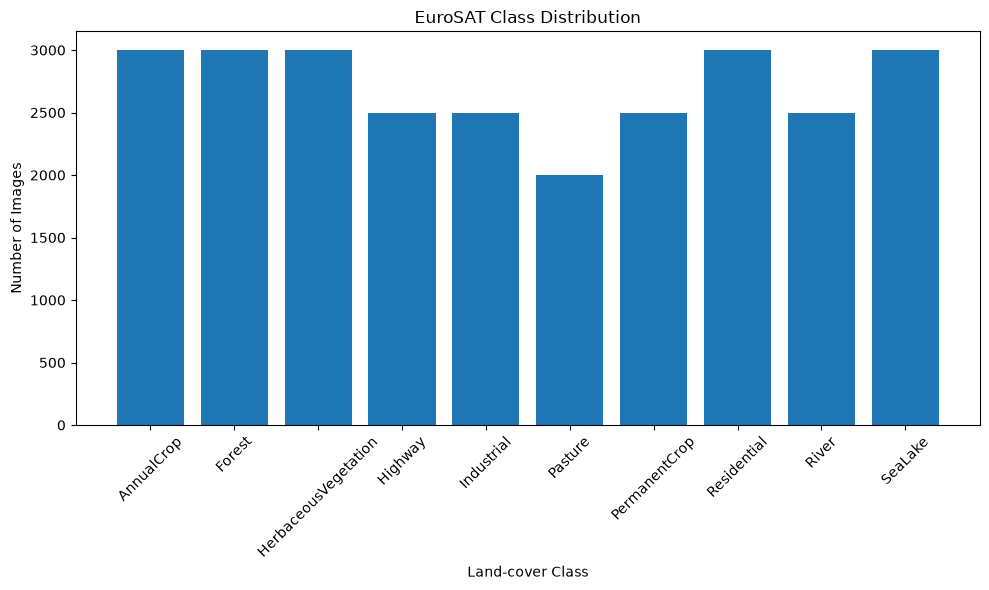

Figure saved at:
C:\Users\jaswa\AI_ML\Assignment 03\EuroSAT_Classification\figures\class_distribution.png


In [8]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

plt.bar(class_counts.keys(), class_counts.values())

plt.xlabel("Land-cover Class")
plt.ylabel("Number of Images")
plt.title("EuroSAT Class Distribution")

plt.xticks(rotation=45)
plt.tight_layout()

save_path = os.path.join(
    figures_path,
    "class_distribution.png"
)

plt.savefig(save_path, dpi=300, bbox_inches="tight")
plt.show()

print("Figure saved at:")
print(save_path)

In [10]:
import os

classes = sorted([
    folder for folder in os.listdir(eurosat_path)
    if os.path.isdir(os.path.join(eurosat_path, folder))
])

print("Number of classes:", len(classes))
print("Classes:")

for i, class_name in enumerate(classes, start=1):
    print(f"{i}. {class_name}")

Number of classes: 10
Classes:
1. AnnualCrop
2. Forest
3. HerbaceousVegetation
4. Highway
5. Industrial
6. Pasture
7. PermanentCrop
8. Residential
9. River
10. SeaLake


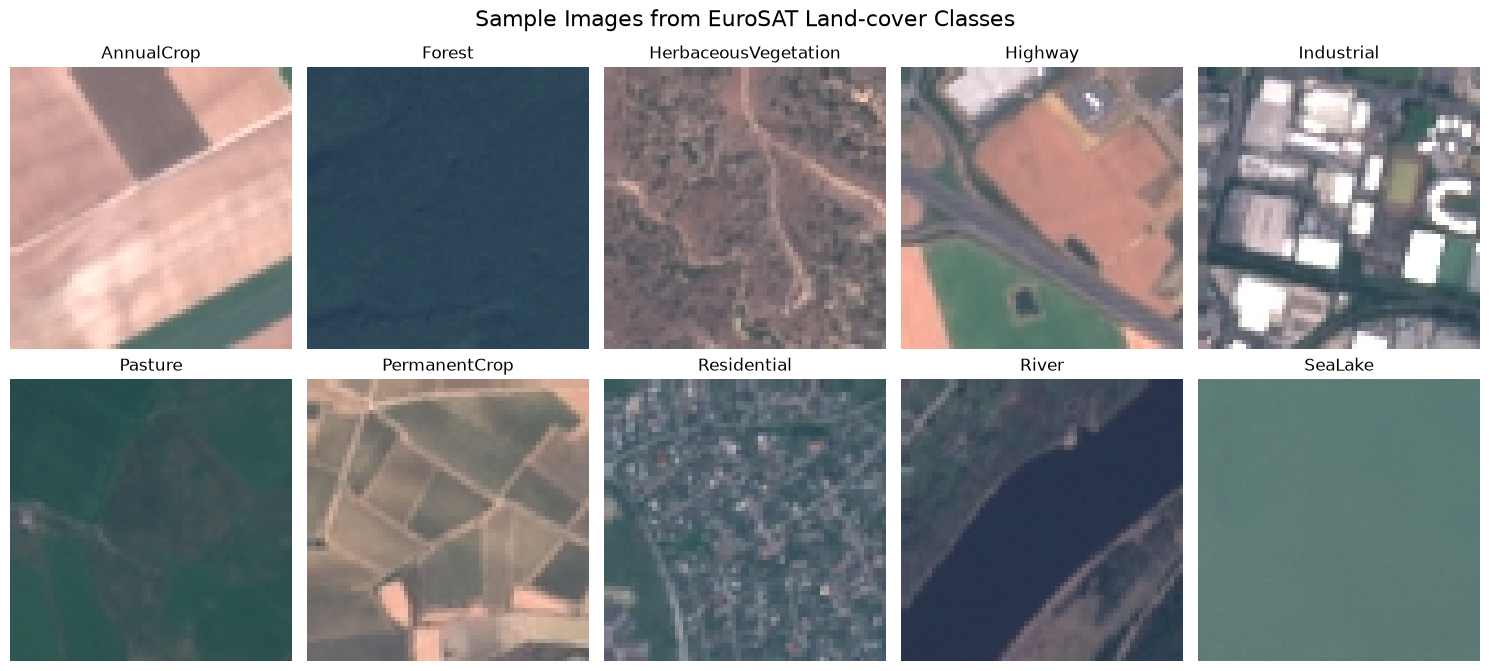

Figure saved at:
C:\Users\jaswa\AI_ML\Assignment 03\EuroSAT_Classification\figures\sample_images.png


In [11]:
from PIL import Image
import random
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 5, figsize=(15, 7))

for ax, class_name in zip(axes.ravel(), classes):

    class_path = os.path.join(eurosat_path, class_name)

    image_files = [
        file for file in os.listdir(class_path)
        if file.lower().endswith((".jpg", ".jpeg", ".png"))
    ]

    image_file = random.choice(image_files)
    image_path = os.path.join(class_path, image_file)

    image = Image.open(image_path)

    ax.imshow(image)
    ax.set_title(class_name)
    ax.axis("off")

plt.suptitle(
    "Sample Images from EuroSAT Land-cover Classes",
    fontsize=16
)

plt.tight_layout()

save_path = os.path.join(
    figures_path,
    "sample_images.png"
)

plt.savefig(save_path, dpi=300, bbox_inches="tight")
plt.show()

print("Figure saved at:")
print(save_path)

In [12]:
import numpy as np
from PIL import Image

X = []
y = []

image_size = (32, 32)

for class_index, class_name in enumerate(classes):

    class_path = os.path.join(eurosat_path, class_name)

    image_files = [
        file for file in os.listdir(class_path)
        if file.lower().endswith((".jpg", ".jpeg", ".png"))
    ]

    for image_file in image_files:

        image_path = os.path.join(class_path, image_file)

        image = Image.open(image_path).convert("RGB")
        image = image.resize(image_size)

        image_array = np.array(image)

        # Convert image into a 1D numerical feature vector
        feature_vector = image_array.flatten()

        X.append(feature_vector)
        y.append(class_index)

X = np.array(X)
y = np.array(y)

print("Feature matrix shape:", X.shape)
print("Label array shape:", y.shape)
print("Number of features per image:", X.shape[1])

Feature matrix shape: (27000, 3072)
Label array shape: (27000,)
Number of features per image: 3072


In [13]:
print("Feature data type:", X.dtype)
print("Label data type:", y.dtype)

print("\nMissing values in X:", np.isnan(X).sum())
print("Missing values in y:", np.isnan(y).sum())

print("\nNumber of samples:", X.shape[0])
print("Number of features:", X.shape[1])
print("Number of labels:", len(y))

print("\nUnique class labels:", np.unique(y))

Feature data type: uint8
Label data type: int64

Missing values in X: 0
Missing values in y: 0

Number of samples: 27000
Number of features: 3072
Number of labels: 27000

Unique class labels: [0 1 2 3 4 5 6 7 8 9]


In [14]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])

print("\nTraining feature shape:", X_train.shape)
print("Testing feature shape:", X_test.shape)

print("\nTraining labels:", y_train.shape)
print("Testing labels:", y_test.shape)

Training samples: 21600
Testing samples: 5400

Training feature shape: (21600, 3072)
Testing feature shape: (5400, 3072)

Training labels: (21600,)
Testing labels: (5400,)


In [15]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Original training shape:", X_train.shape)
print("Scaled training shape:", X_train_scaled.shape)

print("\nOriginal testing shape:", X_test.shape)
print("Scaled testing shape:", X_test_scaled.shape)

print("\nMean of first 5 scaled features:")
print(X_train_scaled[:, :5].mean(axis=0))

print("\nStandard deviation of first 5 scaled features:")
print(X_train_scaled[:, :5].std(axis=0))

Original training shape: (21600, 3072)
Scaled training shape: (21600, 3072)

Original testing shape: (5400, 3072)
Scaled testing shape: (5400, 3072)

Mean of first 5 scaled features:
[-1.20880672e-16 -1.91811587e-16 -2.90744794e-16 -9.70005969e-17
  1.54752754e-16]

Standard deviation of first 5 scaled features:
[1. 1. 1. 1. 1.]


In [16]:
from sklearn.model_selection import train_test_split

# Select a subset for t-SNE visualization
X_tsne, _, y_tsne, _ = train_test_split(
    X_train_scaled,
    y_train,
    train_size=3000,
    random_state=42,
    stratify=y_train
)

print("t-SNE data shape:", X_tsne.shape)
print("t-SNE labels shape:", y_tsne.shape)
print("Number of classes:", len(np.unique(y_tsne)))

t-SNE data shape: (3000, 3072)
t-SNE labels shape: (3000,)
Number of classes: 10


In [17]:
from sklearn.manifold import TSNE
import time

print("Running t-SNE... Please wait.")

tsne_start = time.time()

tsne = TSNE(
    n_components=2,
    random_state=42,
    perplexity=30,
    max_iter=1000,
    init="pca"
)

X_tsne_2d = tsne.fit_transform(X_tsne)

tsne_time = time.time() - tsne_start

print("t-SNE completed.")
print("2D t-SNE shape:", X_tsne_2d.shape)
print(f"t-SNE execution time: {tsne_time:.2f} seconds")

Running t-SNE... Please wait.
t-SNE completed.
2D t-SNE shape: (3000, 2)
t-SNE execution time: 11.25 seconds


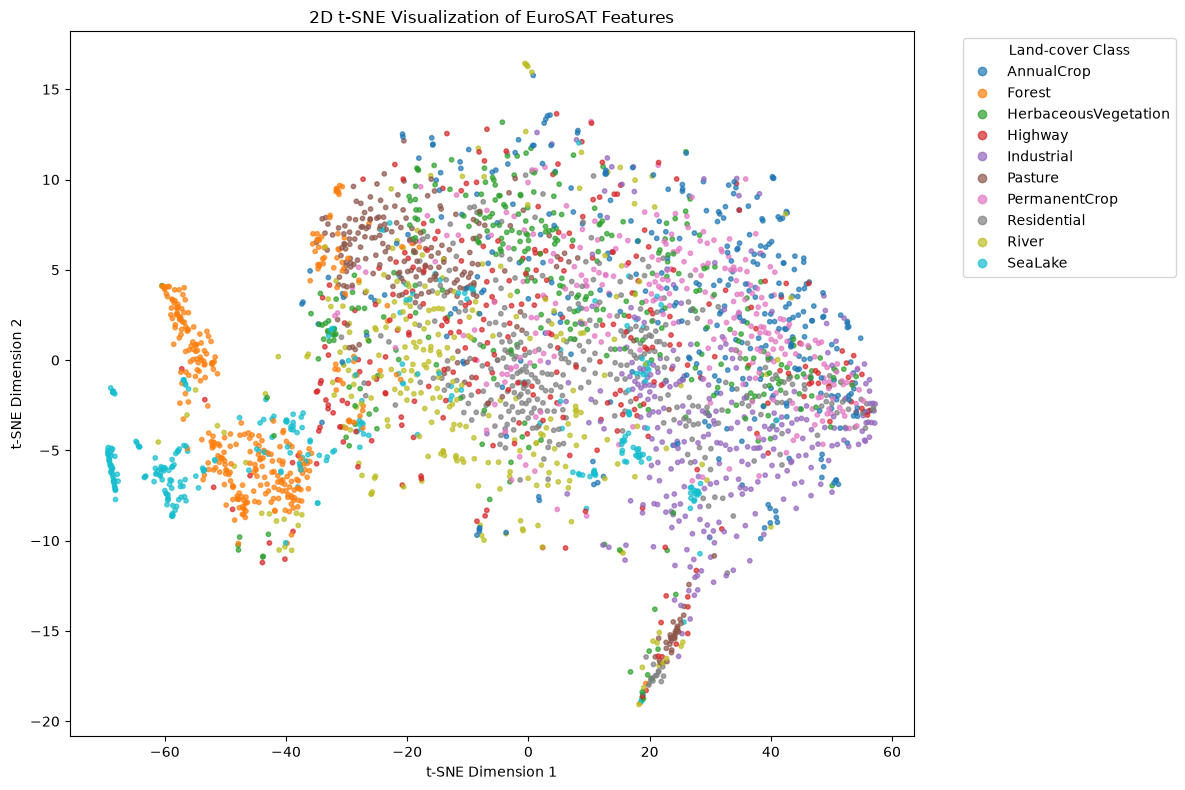

Figure saved at:
C:\Users\jaswa\AI_ML\Assignment 03\EuroSAT_Classification\figures\tsne_2d.png


In [18]:
import matplotlib.pyplot as plt
import numpy as np

plt.figure(figsize=(12, 8))

scatter = plt.scatter(
    X_tsne_2d[:, 0],
    X_tsne_2d[:, 1],
    c=y_tsne,
    cmap="tab10",
    s=10,
    alpha=0.7
)

# Create legend using the class names
handles, _ = scatter.legend_elements()

plt.legend(
    handles,
    classes,
    title="Land-cover Class",
    bbox_to_anchor=(1.05, 1),
    loc="upper left"
)

plt.xlabel("t-SNE Dimension 1")
plt.ylabel("t-SNE Dimension 2")
plt.title("2D t-SNE Visualization of EuroSAT Features")

plt.tight_layout()

save_path = os.path.join(
    figures_path,
    "tsne_2d.png"
)

plt.savefig(save_path, dpi=300, bbox_inches="tight")
plt.show()

print("Figure saved at:")
print(save_path)

In [19]:
import time

classification_start_time = time.time()

print("Classification model experiments started.")

Classification model experiments started.


In [20]:
from sklearn.svm import SVC
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

# Create Linear SVM
linear_svm = SVC(
    kernel="linear",
    random_state=42
)

# Training
train_start = time.time()

linear_svm.fit(X_train_scaled, y_train)

linear_train_time = time.time() - train_start

# Prediction
predict_start = time.time()

y_pred_linear = linear_svm.predict(X_test_scaled)

linear_prediction_time = time.time() - predict_start

# Evaluation metrics
linear_accuracy = accuracy_score(y_test, y_pred_linear)

linear_precision = precision_score(
    y_test,
    y_pred_linear,
    average="weighted"
)

linear_recall = recall_score(
    y_test,
    y_pred_linear,
    average="weighted"
)

linear_f1 = f1_score(
    y_test,
    y_pred_linear,
    average="weighted"
)

print("Linear SVM completed.\n")

print(f"Training time: {linear_train_time:.2f} seconds")
print(f"Prediction time: {linear_prediction_time:.2f} seconds")

print(f"\nAccuracy : {linear_accuracy:.4f}")
print(f"Precision: {linear_precision:.4f}")
print(f"Recall   : {linear_recall:.4f}")
print(f"F1-score : {linear_f1:.4f}")

Linear SVM completed.

Training time: 2124.75 seconds
Prediction time: 139.48 seconds

Accuracy : 0.4296
Precision: 0.4335
Recall   : 0.4296
F1-score : 0.4258


<Figure size 1000x800 with 0 Axes>

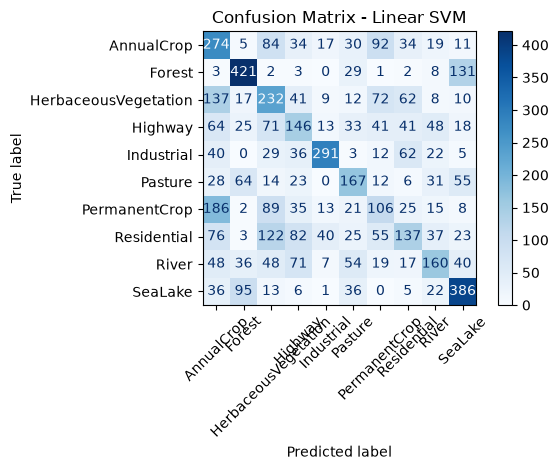

Figure saved at:
C:\Users\jaswa\AI_ML\Assignment 03\EuroSAT_Classification\figures\confusion_matrix_linear_svm.png


In [21]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm_linear = confusion_matrix(y_test, y_pred_linear)

plt.figure(figsize=(10, 8))

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_linear,
    display_labels=classes
)

disp.plot(
    cmap="Blues",
    xticks_rotation=45,
    values_format="d"
)

plt.title("Confusion Matrix - Linear SVM")
plt.tight_layout()

save_path = os.path.join(
    figures_path,
    "confusion_matrix_linear_svm.png"
)

plt.savefig(save_path, dpi=300, bbox_inches="tight")
plt.show()

print("Figure saved at:")
print(save_path)

In [22]:
from sklearn.metrics import classification_report

linear_report = classification_report(
    y_test,
    y_pred_linear,
    target_names=classes,
    digits=4
)

print("Linear SVM Classification Report\n")
print(linear_report)

# Save the report automatically
report_path = os.path.join(
    results_path,
    "linear_svm_classification_report.txt"
)

with open(report_path, "w") as file:
    file.write("Linear SVM Classification Report\n\n")
    file.write(linear_report)

print("Report saved at:")
print(report_path)

Linear SVM Classification Report

                      precision    recall  f1-score   support

          AnnualCrop     0.3072    0.4567    0.3673       600
              Forest     0.6302    0.7017    0.6640       600
HerbaceousVegetation     0.3295    0.3867    0.3558       600
             Highway     0.3061    0.2920    0.2989       500
          Industrial     0.7442    0.5820    0.6532       500
             Pasture     0.4073    0.4175    0.4123       400
       PermanentCrop     0.2585    0.2120    0.2330       500
         Residential     0.3504    0.2283    0.2765       600
               River     0.4324    0.3200    0.3678       500
             SeaLake     0.5619    0.6433    0.5998       600

            accuracy                         0.4296      5400
           macro avg     0.4328    0.4240    0.4229      5400
        weighted avg     0.4335    0.4296    0.4258      5400

Report saved at:
C:\Users\jaswa\AI_ML\Assignment 03\EuroSAT_Classification\results\linear_svm_c

In [23]:
# Create Polynomial Kernel SVM
poly_svm = SVC(
    kernel="poly",
    degree=3,
    random_state=42
)

# Training
train_start = time.time()

poly_svm.fit(X_train_scaled, y_train)

poly_train_time = time.time() - train_start

# Prediction
predict_start = time.time()

y_pred_poly = poly_svm.predict(X_test_scaled)

poly_prediction_time = time.time() - predict_start

# Evaluation metrics
poly_accuracy = accuracy_score(y_test, y_pred_poly)

poly_precision = precision_score(
    y_test,
    y_pred_poly,
    average="weighted"
)

poly_recall = recall_score(
    y_test,
    y_pred_poly,
    average="weighted"
)

poly_f1 = f1_score(
    y_test,
    y_pred_poly,
    average="weighted"
)

print("Polynomial SVM completed.\n")

print(f"Training time: {poly_train_time:.2f} seconds")
print(f"Prediction time: {poly_prediction_time:.2f} seconds")

print(f"\nAccuracy : {poly_accuracy:.4f}")
print(f"Precision: {poly_precision:.4f}")
print(f"Recall   : {poly_recall:.4f}")
print(f"F1-score : {poly_f1:.4f}")

Polynomial SVM completed.

Training time: 635.38 seconds
Prediction time: 190.08 seconds

Accuracy : 0.4915
Precision: 0.5816
Recall   : 0.4915
F1-score : 0.4866


<Figure size 1000x800 with 0 Axes>

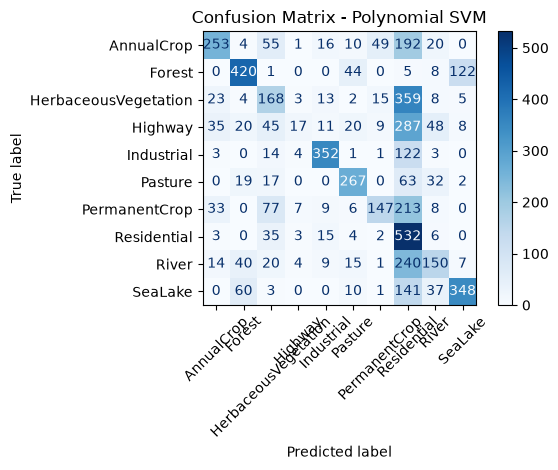

Figure saved at:
C:\Users\jaswa\AI_ML\Assignment 03\EuroSAT_Classification\figures\confusion_matrix_polynomial_svm.png


In [24]:
cm_poly = confusion_matrix(y_test, y_pred_poly)

plt.figure(figsize=(10, 8))

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_poly,
    display_labels=classes
)

disp.plot(
    cmap="Blues",
    xticks_rotation=45,
    values_format="d"
)

plt.title("Confusion Matrix - Polynomial SVM")
plt.tight_layout()

save_path = os.path.join(
    figures_path,
    "confusion_matrix_polynomial_svm.png"
)

plt.savefig(save_path, dpi=300, bbox_inches="tight")
plt.show()

print("Figure saved at:")
print(save_path)

In [25]:
from sklearn.metrics import classification_report

poly_report = classification_report(
    y_test,
    y_pred_poly,
    target_names=classes,
    digits=4
)

print("Polynomial SVM Classification Report\n")
print(poly_report)

# Save the report
report_path = os.path.join(
    results_path,
    "polynomial_svm_classification_report.txt"
)

with open(report_path, "w") as file:
    file.write("Polynomial SVM Classification Report\n\n")
    file.write(poly_report)

print("Report saved at:")
print(report_path)

Polynomial SVM Classification Report

                      precision    recall  f1-score   support

          AnnualCrop     0.6951    0.4217    0.5249       600
              Forest     0.7407    0.7000    0.7198       600
HerbaceousVegetation     0.3862    0.2800    0.3246       600
             Highway     0.4359    0.0340    0.0631       500
          Industrial     0.8282    0.7040    0.7611       500
             Pasture     0.7045    0.6675    0.6855       400
       PermanentCrop     0.6533    0.2940    0.4055       500
         Residential     0.2470    0.8867    0.3863       600
               River     0.4688    0.3000    0.3659       500
             SeaLake     0.7073    0.5800    0.6374       600

            accuracy                         0.4915      5400
           macro avg     0.5867    0.4868    0.4874      5400
        weighted avg     0.5816    0.4915    0.4866      5400

Report saved at:
C:\Users\jaswa\AI_ML\Assignment 03\EuroSAT_Classification\results\polynomi

In [27]:
# Create a representative subset for RBF SVM

X_rbf_train, _, y_rbf_train, _ = train_test_split(
    X_train_scaled,
    y_train,
    train_size=5000,
    random_state=42,
    stratify=y_train
)

print("RBF training subset shape:", X_rbf_train.shape)
print("RBF training labels shape:", y_rbf_train.shape)
print("Number of classes:", len(np.unique(y_rbf_train)))

RBF training subset shape: (5000, 3072)
RBF training labels shape: (5000,)
Number of classes: 10


In [28]:
# Create RBF SVM
rbf_svm = SVC(
    kernel="rbf",
    C=1.0,
    gamma="scale",
    random_state=42
)

# Training
train_start = time.time()

rbf_svm.fit(X_rbf_train, y_rbf_train)

rbf_train_time = time.time() - train_start

# Prediction
predict_start = time.time()

y_pred_rbf = rbf_svm.predict(X_test_scaled)

rbf_prediction_time = time.time() - predict_start

# Evaluation metrics
rbf_accuracy = accuracy_score(y_test, y_pred_rbf)

rbf_precision = precision_score(
    y_test,
    y_pred_rbf,
    average="weighted"
)

rbf_recall = recall_score(
    y_test,
    y_pred_rbf,
    average="weighted"
)

rbf_f1 = f1_score(
    y_test,
    y_pred_rbf,
    average="weighted"
)

print("RBF SVM completed.\n")

print(f"Training samples used: {len(y_rbf_train)}")
print(f"Training time: {rbf_train_time:.2f} seconds")
print(f"Prediction time: {rbf_prediction_time:.2f} seconds")

print(f"\nAccuracy : {rbf_accuracy:.4f}")
print(f"Precision: {rbf_precision:.4f}")
print(f"Recall   : {rbf_recall:.4f}")
print(f"F1-score : {rbf_f1:.4f}")

RBF SVM completed.

Training samples used: 5000
Training time: 40.43 seconds
Prediction time: 92.88 seconds

Accuracy : 0.6100
Precision: 0.6130
Recall   : 0.6100
F1-score : 0.6005


<Figure size 1000x800 with 0 Axes>

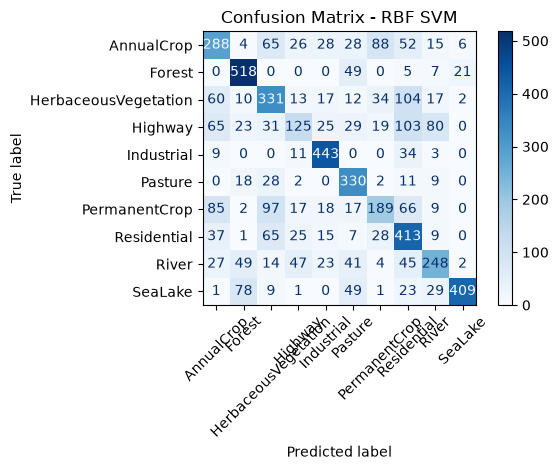

Figure saved at:
C:\Users\jaswa\AI_ML\Assignment 03\EuroSAT_Classification\figures\confusion_matrix_rbf_svm.png


In [29]:
cm_rbf = confusion_matrix(y_test, y_pred_rbf)

plt.figure(figsize=(10, 8))

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_rbf,
    display_labels=classes
)

disp.plot(
    cmap="Blues",
    xticks_rotation=45,
    values_format="d"
)

plt.title("Confusion Matrix - RBF SVM")
plt.tight_layout()

save_path = os.path.join(
    figures_path,
    "confusion_matrix_rbf_svm.png"
)

plt.savefig(save_path, dpi=300, bbox_inches="tight")
plt.show()

print("Figure saved at:")
print(save_path)

In [30]:
rbf_report = classification_report(
    y_test,
    y_pred_rbf,
    target_names=classes,
    digits=4
)

print("RBF SVM Classification Report\n")
print(rbf_report)

# Save the report
report_path = os.path.join(
    results_path,
    "rbf_svm_classification_report.txt"
)

with open(report_path, "w") as file:
    file.write("RBF SVM Classification Report\n\n")
    file.write(rbf_report)

print("Report saved at:")
print(report_path)

RBF SVM Classification Report

                      precision    recall  f1-score   support

          AnnualCrop     0.5035    0.4800    0.4915       600
              Forest     0.7368    0.8633    0.7951       600
HerbaceousVegetation     0.5172    0.5517    0.5339       600
             Highway     0.4682    0.2500    0.3259       500
          Industrial     0.7786    0.8860    0.8288       500
             Pasture     0.5872    0.8250    0.6861       400
       PermanentCrop     0.5178    0.3780    0.4370       500
         Residential     0.4825    0.6883    0.5673       600
               River     0.5822    0.4960    0.5356       500
             SeaLake     0.9295    0.6817    0.7865       600

            accuracy                         0.6100      5400
           macro avg     0.6103    0.6100    0.5988      5400
        weighted avg     0.6130    0.6100    0.6005      5400

Report saved at:
C:\Users\jaswa\AI_ML\Assignment 03\EuroSAT_Classification\results\rbf_svm_classif

In [31]:
from sklearn.tree import DecisionTreeClassifier

# Create Decision Tree
dt_1 = DecisionTreeClassifier(
    max_depth=10,
    min_samples_split=2,
    random_state=42
)

# Training
train_start = time.time()

dt_1.fit(X_train_scaled, y_train)

dt_1_train_time = time.time() - train_start

# Prediction
predict_start = time.time()

y_pred_dt_1 = dt_1.predict(X_test_scaled)

dt_1_prediction_time = time.time() - predict_start

# Evaluation metrics
dt_1_accuracy = accuracy_score(y_test, y_pred_dt_1)

dt_1_precision = precision_score(
    y_test,
    y_pred_dt_1,
    average="weighted"
)

dt_1_recall = recall_score(
    y_test,
    y_pred_dt_1,
    average="weighted"
)

dt_1_f1 = f1_score(
    y_test,
    y_pred_dt_1,
    average="weighted"
)

print("Decision Tree 1 completed.\n")

print("Parameters:")
print("max_depth =", 10)
print("min_samples_split =", 2)

print(f"\nTraining time: {dt_1_train_time:.2f} seconds")
print(f"Prediction time: {dt_1_prediction_time:.2f} seconds")

print(f"\nAccuracy : {dt_1_accuracy:.4f}")
print(f"Precision: {dt_1_precision:.4f}")
print(f"Recall   : {dt_1_recall:.4f}")
print(f"F1-score : {dt_1_f1:.4f}")

Decision Tree 1 completed.

Parameters:
max_depth = 10
min_samples_split = 2

Training time: 43.49 seconds
Prediction time: 0.04 seconds

Accuracy : 0.4822
Precision: 0.4889
Recall   : 0.4822
F1-score : 0.4785


<Figure size 1000x800 with 0 Axes>

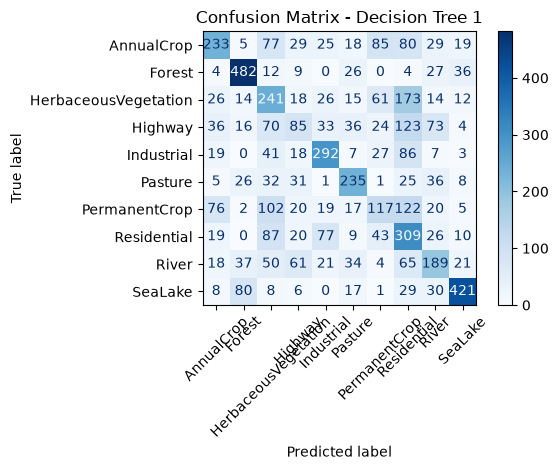

Figure saved at:
C:\Users\jaswa\AI_ML\Assignment 03\EuroSAT_Classification\figures\confusion_matrix_decision_tree_1.png


In [32]:
cm_dt_1 = confusion_matrix(y_test, y_pred_dt_1)

plt.figure(figsize=(10, 8))

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_dt_1,
    display_labels=classes
)

disp.plot(
    cmap="Blues",
    xticks_rotation=45,
    values_format="d"
)

plt.title("Confusion Matrix - Decision Tree 1")
plt.tight_layout()

save_path = os.path.join(
    figures_path,
    "confusion_matrix_decision_tree_1.png"
)

plt.savefig(save_path, dpi=300, bbox_inches="tight")
plt.show()

print("Figure saved at:")
print(save_path)

In [33]:
dt_1_report = classification_report(
    y_test,
    y_pred_dt_1,
    target_names=classes,
    digits=4
)

print("Decision Tree 1 Classification Report\n")
print(dt_1_report)

# Save the report
report_path = os.path.join(
    results_path,
    "decision_tree_1_classification_report.txt"
)

with open(report_path, "w") as file:
    file.write("Decision Tree 1 Classification Report\n\n")
    file.write(dt_1_report)

print("Report saved at:")
print(report_path)

Decision Tree 1 Classification Report

                      precision    recall  f1-score   support

          AnnualCrop     0.5248    0.3883    0.4464       600
              Forest     0.7281    0.8033    0.7639       600
HerbaceousVegetation     0.3347    0.4017    0.3652       600
             Highway     0.2862    0.1700    0.2133       500
          Industrial     0.5911    0.5840    0.5875       500
             Pasture     0.5676    0.5875    0.5774       400
       PermanentCrop     0.3223    0.2340    0.2711       500
         Residential     0.3041    0.5150    0.3824       600
               River     0.4191    0.3780    0.3975       500
             SeaLake     0.7811    0.7017    0.7392       600

            accuracy                         0.4822      5400
           macro avg     0.4859    0.4764    0.4744      5400
        weighted avg     0.4889    0.4822    0.4785      5400

Report saved at:
C:\Users\jaswa\AI_ML\Assignment 03\EuroSAT_Classification\results\decisio

In [34]:
# Create Decision Tree 2
dt_2 = DecisionTreeClassifier(
    max_depth=20,
    min_samples_split=2,
    random_state=42
)

# Training
train_start = time.time()

dt_2.fit(X_train_scaled, y_train)

dt_2_train_time = time.time() - train_start

# Prediction
predict_start = time.time()

y_pred_dt_2 = dt_2.predict(X_test_scaled)

dt_2_prediction_time = time.time() - predict_start

# Evaluation metrics
dt_2_accuracy = accuracy_score(y_test, y_pred_dt_2)

dt_2_precision = precision_score(
    y_test,
    y_pred_dt_2,
    average="weighted"
)

dt_2_recall = recall_score(
    y_test,
    y_pred_dt_2,
    average="weighted"
)

dt_2_f1 = f1_score(
    y_test,
    y_pred_dt_2,
    average="weighted"
)

print("Decision Tree 2 completed.\n")

print("Parameters:")
print("max_depth =", 20)
print("min_samples_split =", 2)

print(f"\nTraining time: {dt_2_train_time:.2f} seconds")
print(f"Prediction time: {dt_2_prediction_time:.2f} seconds")

print(f"\nAccuracy : {dt_2_accuracy:.4f}")
print(f"Precision: {dt_2_precision:.4f}")
print(f"Recall   : {dt_2_recall:.4f}")
print(f"F1-score : {dt_2_f1:.4f}")

Decision Tree 2 completed.

Parameters:
max_depth = 20
min_samples_split = 2

Training time: 68.79 seconds
Prediction time: 0.04 seconds

Accuracy : 0.4752
Precision: 0.4732
Recall   : 0.4752
F1-score : 0.4736


In [35]:
dt_2_report = classification_report(
    y_test,
    y_pred_dt_2,
    target_names=classes,
    digits=4
)

print("Decision Tree 2 Classification Report\n")
print(dt_2_report)

# Save the report
report_path = os.path.join(
    results_path,
    "decision_tree_2_classification_report.txt"
)

with open(report_path, "w") as file:
    file.write("Decision Tree 2 Classification Report\n\n")
    file.write(dt_2_report)

print("Report saved at:")
print(report_path)

Decision Tree 2 Classification Report

                      precision    recall  f1-score   support

          AnnualCrop     0.4010    0.4183    0.4095       600
              Forest     0.7648    0.7967    0.7804       600
HerbaceousVegetation     0.3877    0.4317    0.4085       600
             Highway     0.2562    0.2280    0.2413       500
          Industrial     0.6205    0.5560    0.5865       500
             Pasture     0.5296    0.5375    0.5335       400
       PermanentCrop     0.2515    0.2440    0.2477       500
         Residential     0.3448    0.3683    0.3562       600
               River     0.3891    0.3440    0.3652       500
             SeaLake     0.7427    0.7600    0.7512       600

            accuracy                         0.4752      5400
           macro avg     0.4688    0.4684    0.4680      5400
        weighted avg     0.4732    0.4752    0.4736      5400

Report saved at:
C:\Users\jaswa\AI_ML\Assignment 03\EuroSAT_Classification\results\decisio

<Figure size 1000x800 with 0 Axes>

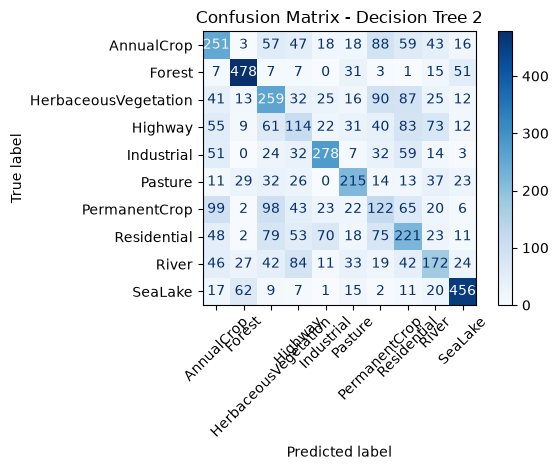

Figure saved at:
C:\Users\jaswa\AI_ML\Assignment 03\EuroSAT_Classification\figures\confusion_matrix_decision_tree_2.png


In [36]:
cm_dt_2 = confusion_matrix(
    y_test,
    y_pred_dt_2
)

plt.figure(figsize=(10, 8))

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_dt_2,
    display_labels=classes
)

disp.plot(
    cmap="Blues",
    xticks_rotation=45,
    values_format="d"
)

plt.title("Confusion Matrix - Decision Tree 2")

plt.tight_layout()

save_path = os.path.join(
    figures_path,
    "confusion_matrix_decision_tree_2.png"
)

plt.savefig(
    save_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Figure saved at:")
print(save_path)

In [37]:
# Create Decision Tree 3
dt_3 = DecisionTreeClassifier(
    max_depth=10,
    min_samples_split=10,
    random_state=42
)

# Training
train_start = time.time()

dt_3.fit(X_train_scaled, y_train)

dt_3_train_time = time.time() - train_start

# Prediction
predict_start = time.time()

y_pred_dt_3 = dt_3.predict(X_test_scaled)

dt_3_prediction_time = time.time() - predict_start

# Evaluation metrics
dt_3_accuracy = accuracy_score(
    y_test,
    y_pred_dt_3
)

dt_3_precision = precision_score(
    y_test,
    y_pred_dt_3,
    average="weighted"
)

dt_3_recall = recall_score(
    y_test,
    y_pred_dt_3,
    average="weighted"
)

dt_3_f1 = f1_score(
    y_test,
    y_pred_dt_3,
    average="weighted"
)

print("Decision Tree 3 completed.\n")

print("Parameters:")
print("max_depth =", 10)
print("min_samples_split =", 10)

print(f"\nTraining time: {dt_3_train_time:.2f} seconds")
print(f"Prediction time: {dt_3_prediction_time:.2f} seconds")

print(f"\nAccuracy : {dt_3_accuracy:.4f}")
print(f"Precision: {dt_3_precision:.4f}")
print(f"Recall   : {dt_3_recall:.4f}")
print(f"F1-score : {dt_3_f1:.4f}")

Decision Tree 3 completed.

Parameters:
max_depth = 10
min_samples_split = 10

Training time: 43.02 seconds
Prediction time: 0.04 seconds

Accuracy : 0.4813
Precision: 0.4880
Recall   : 0.4813
F1-score : 0.4776


In [38]:
dt_3_report = classification_report(
    y_test,
    y_pred_dt_3,
    target_names=classes,
    digits=4
)

print("Decision Tree 3 Classification Report\n")
print(dt_3_report)

# Save the report
report_path = os.path.join(
    results_path,
    "decision_tree_3_classification_report.txt"
)

with open(report_path, "w") as file:
    file.write("Decision Tree 3 Classification Report\n\n")
    file.write(dt_3_report)

print("Report saved at:")
print(report_path)

Decision Tree 3 Classification Report

                      precision    recall  f1-score   support

          AnnualCrop     0.5223    0.3900    0.4466       600
              Forest     0.7337    0.8083    0.7692       600
HerbaceousVegetation     0.3352    0.4000    0.3647       600
             Highway     0.2706    0.1640    0.2042       500
          Industrial     0.5881    0.5740    0.5810       500
             Pasture     0.5649    0.5875    0.5760       400
       PermanentCrop     0.3258    0.2320    0.2710       500
         Residential     0.3030    0.5167    0.3820       600
               River     0.4185    0.3800    0.3983       500
             SeaLake     0.7850    0.7000    0.7401       600

            accuracy                         0.4813      5400
           macro avg     0.4847    0.4753    0.4733      5400
        weighted avg     0.4880    0.4813    0.4776      5400

Report saved at:
C:\Users\jaswa\AI_ML\Assignment 03\EuroSAT_Classification\results\decisio

<Figure size 1000x800 with 0 Axes>

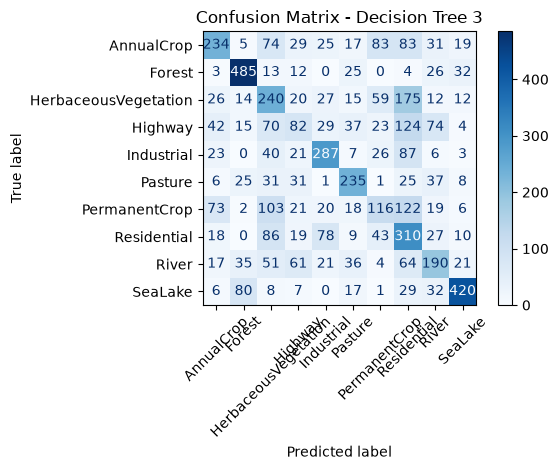

Figure saved at:
C:\Users\jaswa\AI_ML\Assignment 03\EuroSAT_Classification\figures\confusion_matrix_decision_tree_3.png


In [39]:
cm_dt_3 = confusion_matrix(
    y_test,
    y_pred_dt_3
)

plt.figure(figsize=(10, 8))

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_dt_3,
    display_labels=classes
)

disp.plot(
    cmap="Blues",
    xticks_rotation=45,
    values_format="d"
)

plt.title("Confusion Matrix - Decision Tree 3")

plt.tight_layout()

save_path = os.path.join(
    figures_path,
    "confusion_matrix_decision_tree_3.png"
)

plt.savefig(
    save_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Figure saved at:")
print(save_path)

In [40]:
# Create Decision Tree 4
dt_4 = DecisionTreeClassifier(
    max_depth=20,
    min_samples_split=10,
    random_state=42
)

# Training
train_start = time.time()

dt_4.fit(X_train_scaled, y_train)

dt_4_train_time = time.time() - train_start

# Prediction
predict_start = time.time()

y_pred_dt_4 = dt_4.predict(X_test_scaled)

dt_4_prediction_time = time.time() - predict_start

# Evaluation metrics
dt_4_accuracy = accuracy_score(
    y_test,
    y_pred_dt_4
)

dt_4_precision = precision_score(
    y_test,
    y_pred_dt_4,
    average="weighted"
)

dt_4_recall = recall_score(
    y_test,
    y_pred_dt_4,
    average="weighted"
)

dt_4_f1 = f1_score(
    y_test,
    y_pred_dt_4,
    average="weighted"
)

print("Decision Tree 4 completed.\n")

print("Parameters:")
print("max_depth =", 20)
print("min_samples_split =", 10)

print(f"\nTraining time: {dt_4_train_time:.2f} seconds")
print(f"Prediction time: {dt_4_prediction_time:.2f} seconds")

print(f"\nAccuracy : {dt_4_accuracy:.4f}")
print(f"Precision: {dt_4_precision:.4f}")
print(f"Recall   : {dt_4_recall:.4f}")
print(f"F1-score : {dt_4_f1:.4f}")

Decision Tree 4 completed.

Parameters:
max_depth = 20
min_samples_split = 10

Training time: 66.94 seconds
Prediction time: 0.04 seconds

Accuracy : 0.4754
Precision: 0.4758
Recall   : 0.4754
F1-score : 0.4748


In [41]:
dt_4_report = classification_report(
    y_test,
    y_pred_dt_4,
    target_names=classes,
    digits=4
)

print("Decision Tree 4 Classification Report\n")
print(dt_4_report)

# Save the report
report_path = os.path.join(
    results_path,
    "decision_tree_4_classification_report.txt"
)

with open(report_path, "w") as file:
    file.write("Decision Tree 4 Classification Report\n\n")
    file.write(dt_4_report)

print("Report saved at:")
print(report_path)

Decision Tree 4 Classification Report

                      precision    recall  f1-score   support

          AnnualCrop     0.3727    0.4100    0.3905       600
              Forest     0.7617    0.7883    0.7748       600
HerbaceousVegetation     0.3802    0.4283    0.4028       600
             Highway     0.2627    0.2480    0.2551       500
          Industrial     0.5918    0.5480    0.5691       500
             Pasture     0.5347    0.5400    0.5373       400
       PermanentCrop     0.2787    0.2620    0.2701       500
         Residential     0.3514    0.3683    0.3596       600
               River     0.4313    0.3580    0.3913       500
             SeaLake     0.7559    0.7433    0.7496       600

            accuracy                         0.4754      5400
           macro avg     0.4721    0.4694    0.4700      5400
        weighted avg     0.4758    0.4754    0.4748      5400

Report saved at:
C:\Users\jaswa\AI_ML\Assignment 03\EuroSAT_Classification\results\decisio

<Figure size 1000x800 with 0 Axes>

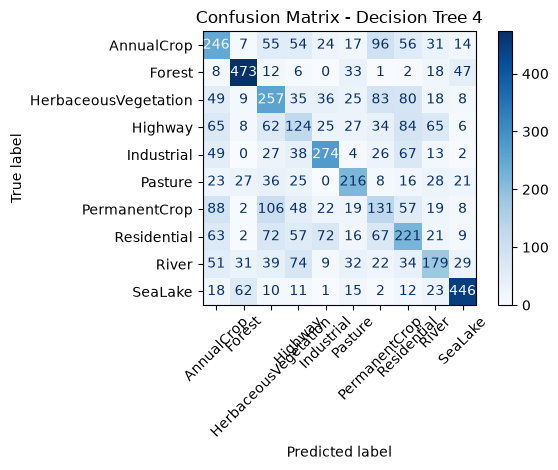

Figure saved at:
C:\Users\jaswa\AI_ML\Assignment 03\EuroSAT_Classification\figures\confusion_matrix_decision_tree_4.png


In [42]:
cm_dt_4 = confusion_matrix(
    y_test,
    y_pred_dt_4
)

plt.figure(figsize=(10, 8))

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_dt_4,
    display_labels=classes
)

disp.plot(
    cmap="Blues",
    xticks_rotation=45,
    values_format="d"
)

plt.title("Confusion Matrix - Decision Tree 4")

plt.tight_layout()

save_path = os.path.join(
    figures_path,
    "confusion_matrix_decision_tree_4.png"
)

plt.savefig(
    save_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Figure saved at:")
print(save_path)

In [43]:
import pandas as pd

model_results = pd.DataFrame([
    {
        "Model": "Linear SVM",
        "Training Samples": len(y_train),
        "Accuracy": linear_accuracy,
        "Precision": linear_precision,
        "Recall": linear_recall,
        "F1-Score": linear_f1,
        "Training Time (s)": linear_train_time,
        "Prediction Time (s)": linear_prediction_time
    },
    {
        "Model": "Polynomial SVM",
        "Training Samples": len(y_train),
        "Accuracy": poly_accuracy,
        "Precision": poly_precision,
        "Recall": poly_recall,
        "F1-Score": poly_f1,
        "Training Time (s)": poly_train_time,
        "Prediction Time (s)": poly_prediction_time
    },
    {
        "Model": "RBF SVM",
        "Training Samples": len(y_rbf_train),
        "Accuracy": rbf_accuracy,
        "Precision": rbf_precision,
        "Recall": rbf_recall,
        "F1-Score": rbf_f1,
        "Training Time (s)": rbf_train_time,
        "Prediction Time (s)": rbf_prediction_time
    },
    {
        "Model": "Decision Tree 1",
        "Training Samples": len(y_train),
        "Accuracy": dt_1_accuracy,
        "Precision": dt_1_precision,
        "Recall": dt_1_recall,
        "F1-Score": dt_1_f1,
        "Training Time (s)": dt_1_train_time,
        "Prediction Time (s)": dt_1_prediction_time
    },
    {
        "Model": "Decision Tree 2",
        "Training Samples": len(y_train),
        "Accuracy": dt_2_accuracy,
        "Precision": dt_2_precision,
        "Recall": dt_2_recall,
        "F1-Score": dt_2_f1,
        "Training Time (s)": dt_2_train_time,
        "Prediction Time (s)": dt_2_prediction_time
    },
    {
        "Model": "Decision Tree 3",
        "Training Samples": len(y_train),
        "Accuracy": dt_3_accuracy,
        "Precision": dt_3_precision,
        "Recall": dt_3_recall,
        "F1-Score": dt_3_f1,
        "Training Time (s)": dt_3_train_time,
        "Prediction Time (s)": dt_3_prediction_time
    },
    {
        "Model": "Decision Tree 4",
        "Training Samples": len(y_train),
        "Accuracy": dt_4_accuracy,
        "Precision": dt_4_precision,
        "Recall": dt_4_recall,
        "F1-Score": dt_4_f1,
        "Training Time (s)": dt_4_train_time,
        "Prediction Time (s)": dt_4_prediction_time
    }
])

print("Model comparison results:\n")
display(model_results)

Model comparison results:



,Model,Training Samples,Accuracy,Precision,Recall,F1-Score,Training Time (s),Prediction Time (s)
0,Linear SVM,21600,0.429630,0.433537,0.429630,0.425826,2124.748327,139.484631
1,Polynomial SVM,21600,0.491481,0.581608,0.491481,0.486627,635.377840,190.078532
2,RBF SVM,5000,0.610000,0.612954,0.610000,0.600497,40.432538,92.875200
3,Decision Tree 1,21600,0.482222,0.488902,0.482222,0.478502,43.492604,0.044078
4,Decision Tree 2,21600,0.475185,0.473163,0.475185,0.473556,68.790123,0.037699
5,Decision Tree 3,21600,0.481296,0.487982,0.481296,0.477639,43.020804,0.043483
6,Decision Tree 4,21600,0.475370,0.475788,0.475370,0.474830,66.939476,0.044163


In [44]:
csv_path = os.path.join(
    results_path,
    "model_comparison_results.csv"
)

model_results.to_csv(
    csv_path,
    index=False
)

print("Model comparison results saved at:")
print(csv_path)

Model comparison results saved at:
C:\Users\jaswa\AI_ML\Assignment 03\EuroSAT_Classification\results\model_comparison_results.csv


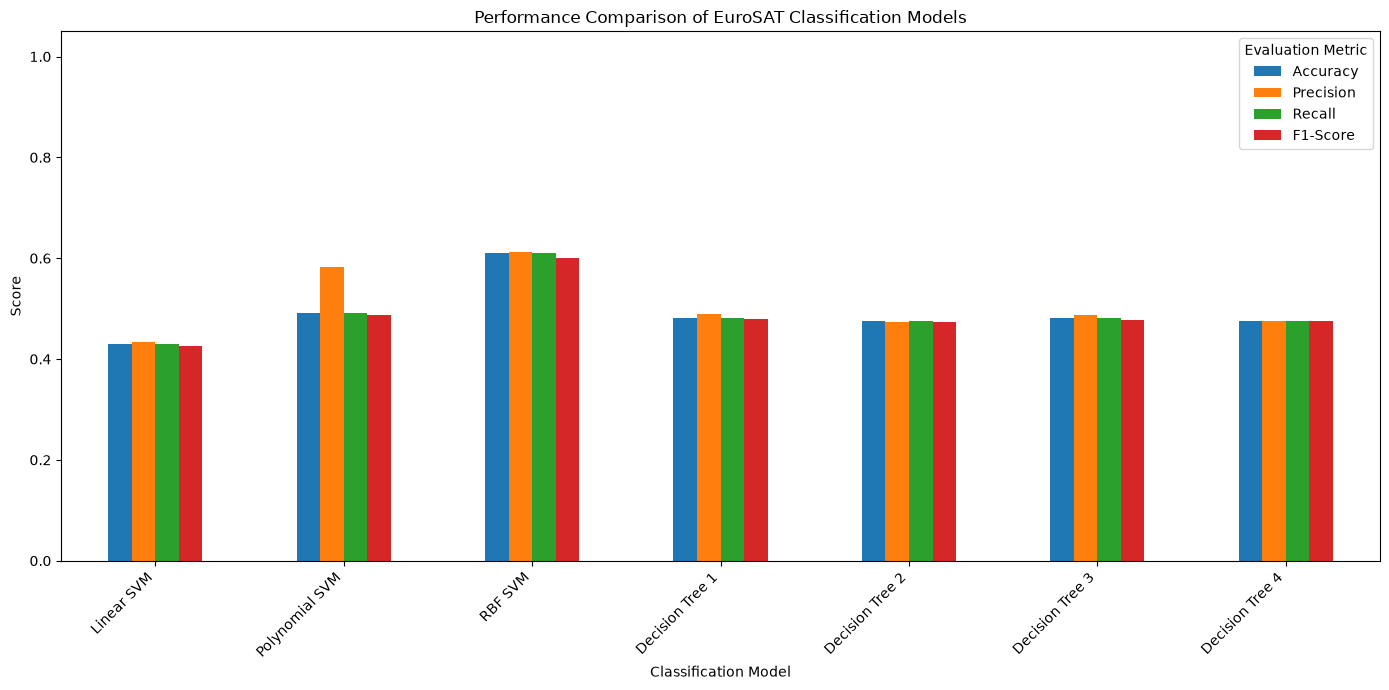

Figure saved at:
C:\Users\jaswa\AI_ML\Assignment 03\EuroSAT_Classification\figures\model_performance_comparison.png


In [45]:
import matplotlib.pyplot as plt

metrics = [
    "Accuracy",
    "Precision",
    "Recall",
    "F1-Score"
]

ax = model_results.set_index("Model")[metrics].plot(
    kind="bar",
    figsize=(14, 7)
)

plt.xlabel("Classification Model")
plt.ylabel("Score")
plt.title("Performance Comparison of EuroSAT Classification Models")

plt.xticks(rotation=45, ha="right")
plt.ylim(0, 1.05)

plt.legend(
    title="Evaluation Metric"
)

plt.tight_layout()

save_path = os.path.join(
    figures_path,
    "model_performance_comparison.png"
)

plt.savefig(
    save_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Figure saved at:")
print(save_path)

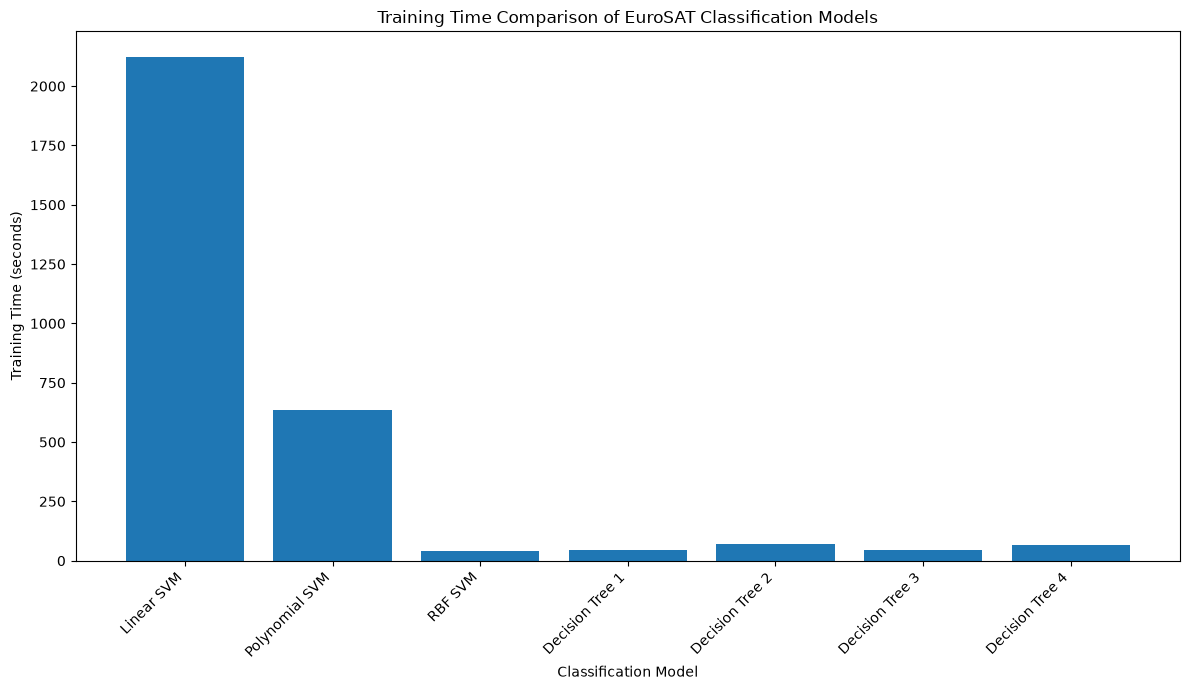

Figure saved at:
C:\Users\jaswa\AI_ML\Assignment 03\EuroSAT_Classification\figures\training_time_comparison.png


In [46]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 7))

plt.bar(
    model_results["Model"],
    model_results["Training Time (s)"]
)

plt.xlabel("Classification Model")
plt.ylabel("Training Time (seconds)")
plt.title("Training Time Comparison of EuroSAT Classification Models")

plt.xticks(
    rotation=45,
    ha="right"
)

plt.tight_layout()

save_path = os.path.join(
    figures_path,
    "training_time_comparison.png"
)

plt.savefig(
    save_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Figure saved at:")
print(save_path)

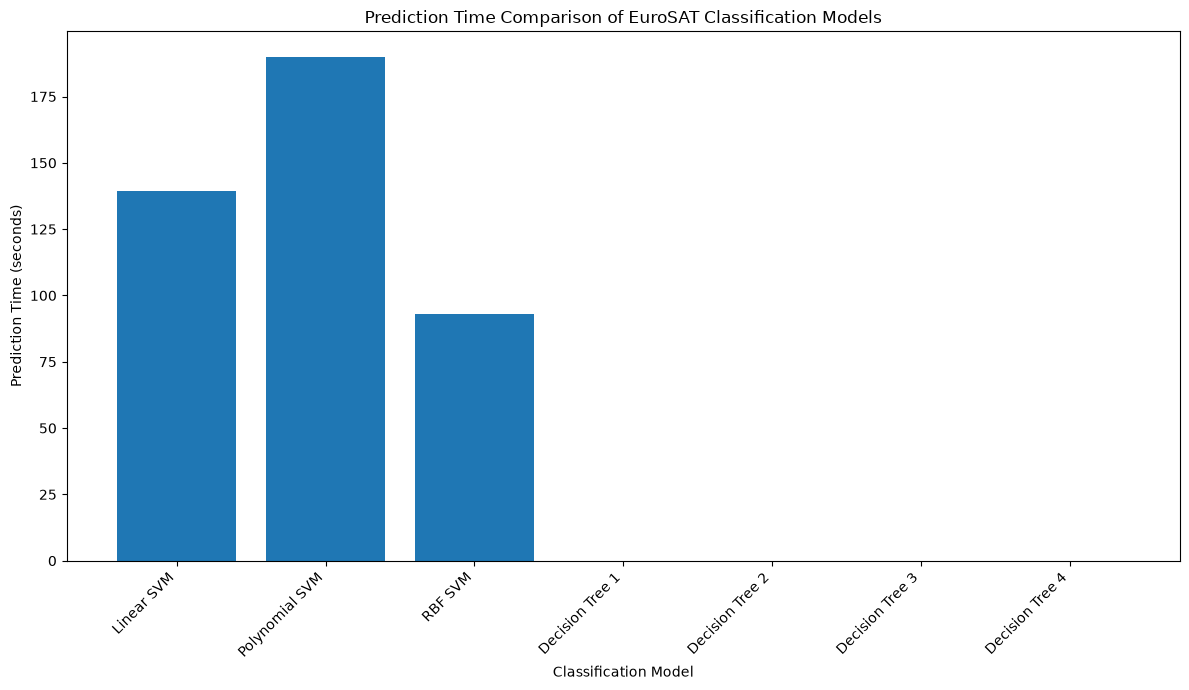

Figure saved at:
C:\Users\jaswa\AI_ML\Assignment 03\EuroSAT_Classification\figures\prediction_time_comparison.png


In [47]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 7))

plt.bar(
    model_results["Model"],
    model_results["Prediction Time (s)"]
)

plt.xlabel("Classification Model")
plt.ylabel("Prediction Time (seconds)")
plt.title("Prediction Time Comparison of EuroSAT Classification Models")

plt.xticks(
    rotation=45,
    ha="right"
)

plt.tight_layout()

save_path = os.path.join(
    figures_path,
    "prediction_time_comparison.png"
)

plt.savefig(
    save_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Figure saved at:")
print(save_path)

In [48]:
import psutil
import pandas as pd
import os

# Current CPU utilization
cpu_usage = psutil.cpu_percent(interval=1)

# Current memory utilization
memory_usage = psutil.virtual_memory().percent

resource_data = pd.DataFrame({
    "Resource": [
        "CPU Utilization",
        "Memory Utilization"
    ],
    "Usage (%)": [
        cpu_usage,
        memory_usage
    ]
})

print("System Resource Utilization\n")
display(resource_data)

resource_path = os.path.join(
    results_path,
    "system_resource_utilization.csv"
)

resource_data.to_csv(
    resource_path,
    index=False
)

print("\nResource utilization saved at:")
print(resource_path)

System Resource Utilization



,Resource,Usage (%)
0,CPU Utilization,10.7
1,Memory Utilization,59.8



Resource utilization saved at:
C:\Users\jaswa\AI_ML\Assignment 03\EuroSAT_Classification\results\system_resource_utilization.csv


In [49]:
total_classification_time = time.time() - classification_start_time

print("Total classification experiment execution time:")
print(f"{total_classification_time:.2f} seconds")

# Save total execution time
execution_time_path = os.path.join(
    results_path,
    "total_execution_time.txt"
)

with open(execution_time_path, "w") as file:
    file.write("Total Classification Experiment Execution Time\n\n")
    file.write(f"{total_classification_time:.2f} seconds\n")

print("\nExecution time saved at:")
print(execution_time_path)

Total classification experiment execution time:
12530.94 seconds

Execution time saved at:
C:\Users\jaswa\AI_ML\Assignment 03\EuroSAT_Classification\results\total_execution_time.txt


In [51]:
# Create a detailed final results table

final_results = pd.DataFrame([
    {
        "Model": "Linear SVM",
        "Parameters": "kernel=linear",
        "Training Samples": len(y_train),
        "Accuracy": linear_accuracy,
        "Precision": linear_precision,
        "Recall": linear_recall,
        "F1-Score": linear_f1,
        "Training Time (s)": linear_train_time,
        "Prediction Time (s)": linear_prediction_time
    },
    {
        "Model": "Polynomial SVM",
        "Parameters": "kernel=poly, degree=3",
        "Training Samples": len(y_train),
        "Accuracy": poly_accuracy,
        "Precision": poly_precision,
        "Recall": poly_recall,
        "F1-Score": poly_f1,
        "Training Time (s)": poly_train_time,
        "Prediction Time (s)": poly_prediction_time
    },
    {
        "Model": "RBF SVM",
        "Parameters": "kernel=rbf, C=1.0, gamma=scale",
        "Training Samples": len(y_rbf_train),
        "Accuracy": rbf_accuracy,
        "Precision": rbf_precision,
        "Recall": rbf_recall,
        "F1-Score": rbf_f1,
        "Training Time (s)": rbf_train_time,
        "Prediction Time (s)": rbf_prediction_time
    },
    {
        "Model": "Decision Tree 1",
        "Parameters": "max_depth=10, min_samples_split=2",
        "Training Samples": len(y_train),
        "Accuracy": dt_1_accuracy,
        "Precision": dt_1_precision,
        "Recall": dt_1_recall,
        "F1-Score": dt_1_f1,
        "Training Time (s)": dt_1_train_time,
        "Prediction Time (s)": dt_1_prediction_time
    },
    {
        "Model": "Decision Tree 2",
        "Parameters": "max_depth=20, min_samples_split=2",
        "Training Samples": len(y_train),
        "Accuracy": dt_2_accuracy,
        "Precision": dt_2_precision,
        "Recall": dt_2_recall,
        "F1-Score": dt_2_f1,
        "Training Time (s)": dt_2_train_time,
        "Prediction Time (s)": dt_2_prediction_time
    },
    {
        "Model": "Decision Tree 3",
        "Parameters": "max_depth=10, min_samples_split=10",
        "Training Samples": len(y_train),
        "Accuracy": dt_3_accuracy,
        "Precision": dt_3_precision,
        "Recall": dt_3_recall,
        "F1-Score": dt_3_f1,
        "Training Time (s)": dt_3_train_time,
        "Prediction Time (s)": dt_3_prediction_time
    },
    {
        "Model": "Decision Tree 4",
        "Parameters": "max_depth=20, min_samples_split=10",
        "Training Samples": len(y_train),
        "Accuracy": dt_4_accuracy,
        "Precision": dt_4_precision,
        "Recall": dt_4_recall,
        "F1-Score": dt_4_f1,
        "Training Time (s)": dt_4_train_time,
        "Prediction Time (s)": dt_4_prediction_time
    }
])

print("FINAL MODEL RESULTS\n")

display(final_results)

# Save final results
final_results_path = os.path.join(
    results_path,
    "final_model_results.csv"
)

final_results.to_csv(
    final_results_path,
    index=False
)

print("\nFinal results saved at:")
print(final_results_path)

FINAL MODEL RESULTS



,Model,Parameters,Training Samples,Accuracy,Precision,Recall,F1-Score,Training Time (s),Prediction Time (s)
0,Linear SVM,kernel=linear,21600,0.429630,0.433537,0.429630,0.425826,2124.748327,139.484631
1,Polynomial SVM,"kernel=poly, degree=3",21600,0.491481,0.581608,0.491481,0.486627,635.377840,190.078532
2,RBF SVM,"kernel=rbf, C=1.0, gamma=scale",5000,0.610000,0.612954,0.610000,0.600497,40.432538,92.875200
3,Decision Tree 1,"max_depth=10, min_samples_split=2",21600,0.482222,0.488902,0.482222,0.478502,43.492604,0.044078
4,Decision Tree 2,"max_depth=20, min_samples_split=2",21600,0.475185,0.473163,0.475185,0.473556,68.790123,0.037699
5,Decision Tree 3,"max_depth=10, min_samples_split=10",21600,0.481296,0.487982,0.481296,0.477639,43.020804,0.043483
6,Decision Tree 4,"max_depth=20, min_samples_split=10",21600,0.475370,0.475788,0.475370,0.474830,66.939476,0.044163



Final results saved at:
C:\Users\jaswa\AI_ML\Assignment 03\EuroSAT_Classification\results\final_model_results.csv


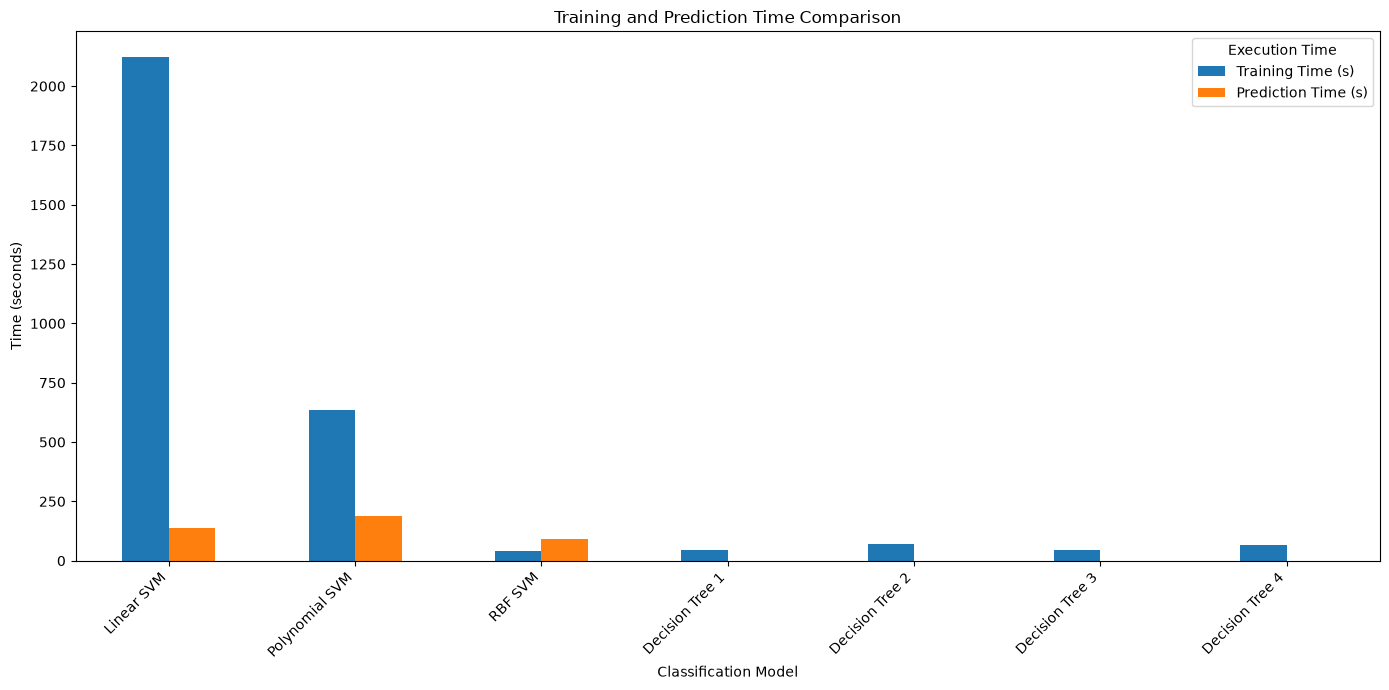

Figure saved at:
C:\Users\jaswa\AI_ML\Assignment 03\EuroSAT_Classification\figures\training_prediction_time_comparison.png


In [52]:
import matplotlib.pyplot as plt

time_data = final_results.set_index("Model")[
    ["Training Time (s)", "Prediction Time (s)"]
]

ax = time_data.plot(
    kind="bar",
    figsize=(14, 7)
)

plt.xlabel("Classification Model")
plt.ylabel("Time (seconds)")
plt.title("Training and Prediction Time Comparison")

plt.xticks(
    rotation=45,
    ha="right"
)

plt.legend(
    title="Execution Time"
)

plt.tight_layout()

save_path = os.path.join(
    figures_path,
    "training_prediction_time_comparison.png"
)

plt.savefig(
    save_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Figure saved at:")
print(save_path)

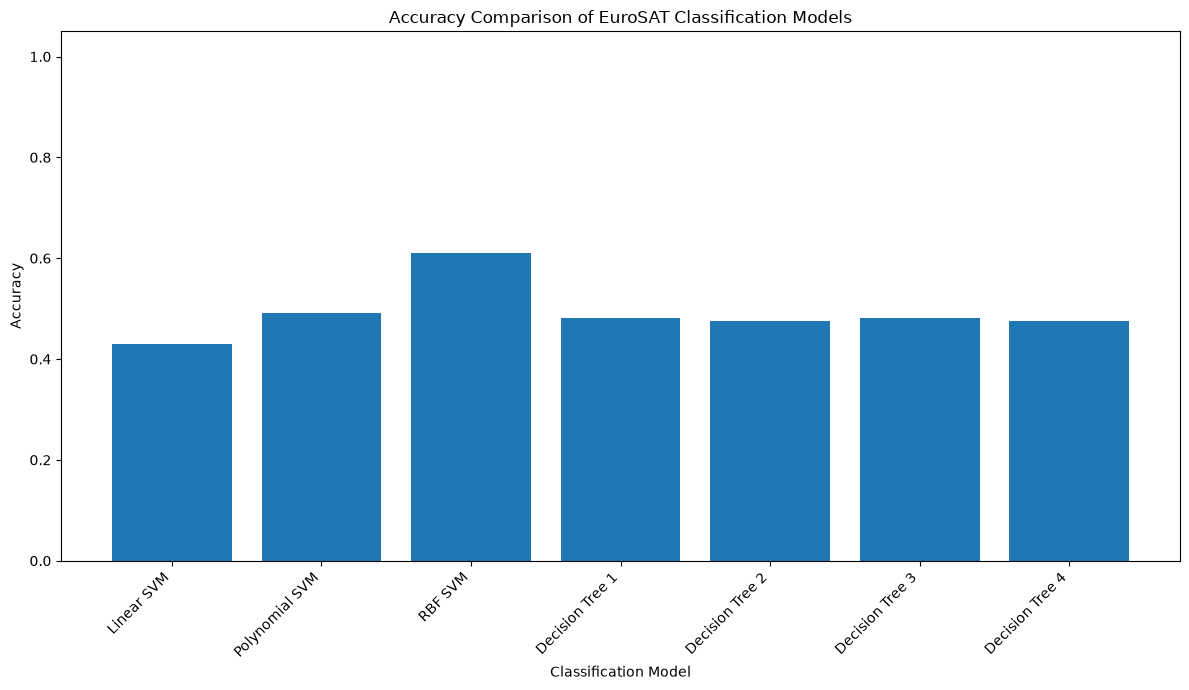

Figure saved at:
C:\Users\jaswa\AI_ML\Assignment 03\EuroSAT_Classification\figures\accuracy_comparison.png


In [53]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 7))

plt.bar(
    final_results["Model"],
    final_results["Accuracy"]
)

plt.xlabel("Classification Model")
plt.ylabel("Accuracy")
plt.title("Accuracy Comparison of EuroSAT Classification Models")

plt.xticks(
    rotation=45,
    ha="right"
)

plt.ylim(0, 1.05)

plt.tight_layout()

save_path = os.path.join(
    figures_path,
    "accuracy_comparison.png"
)

plt.savefig(
    save_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Figure saved at:")
print(save_path)

In [54]:
summary_path = os.path.join(
    results_path,
    "experiment_summary.txt"
)

with open(summary_path, "w") as file:

    file.write("EuroSAT Classification Experiment Summary\n")
    file.write("=" * 55 + "\n\n")

    file.write("Dataset: EuroSAT RGB\n")
    file.write(f"Number of classes: {len(classes)}\n")
    file.write(f"Total images: {len(X)}\n")
    file.write(f"Image size used: {image_size[0]} x {image_size[1]}\n")
    file.write(f"Features per image: {X.shape[1]}\n")
    file.write("Train-test split: 80% training / 20% testing\n\n")

    file.write("Classification Models\n")
    file.write("-" * 55 + "\n")

    for _, row in final_results.iterrows():

        file.write(f"\nModel: {row['Model']}\n")
        file.write(f"Parameters: {row['Parameters']}\n")
        file.write(f"Training Samples: {row['Training Samples']}\n")
        file.write(f"Accuracy: {row['Accuracy']:.4f}\n")
        file.write(f"Precision: {row['Precision']:.4f}\n")
        file.write(f"Recall: {row['Recall']:.4f}\n")
        file.write(f"F1-Score: {row['F1-Score']:.4f}\n")
        file.write(f"Training Time: {row['Training Time (s)']:.2f} seconds\n")
        file.write(f"Prediction Time: {row['Prediction Time (s)']:.2f} seconds\n")

    file.write("\n")
    file.write("System Resource Utilization\n")
    file.write("-" * 55 + "\n")
    file.write(f"CPU Utilization: {cpu_usage:.2f}%\n")
    file.write(f"Memory Utilization: {memory_usage:.2f}%\n")

    file.write("\n")
    file.write("Total Classification Experiment Time\n")
    file.write("-" * 55 + "\n")
    file.write(
        f"{total_classification_time:.2f} seconds\n"
    )

print("Experiment summary saved at:")
print(summary_path)

Experiment summary saved at:
C:\Users\jaswa\AI_ML\Assignment 03\EuroSAT_Classification\results\experiment_summary.txt
